In [255]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [263]:
# build vocabulary, mappings from chars to ints
# and ints to chars, ints are the indexes
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [288]:
# build dataset

def build_dataset(words):
    block_size = 3 # how many chars we sue t predict next one
    X, Y = [], []

    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [289]:
g = torch.Generator().manual_seed(42)
C = torch.randn((27, 2),                    requires_grad=True)
W1 = torch.randn((6, 300), generator=g,     requires_grad=True)
b1 = torch.randn(300, generator=g,          requires_grad=True)
W2 = torch.randn((300, 27), generator=g,    requires_grad=True)
b2 = torch.randn(27, generator=g,           requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [234]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [305]:
lri = []
lossi = []
stepi = []

for i in range(30000):
    # mini batch 32
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # forward pass
    emb = C[Xtr[ix]] # 32 x 3 x 2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer weights + bias (3x2) x emb
    logits = h @ W2 + b2 # 32 x 27 (output layer)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backwrad pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.05
    for p in parameters:
        p.data += -lr * p.grad

    # tracking stats
    stepi.append(i)
    lossi.append(loss.item())

# print(loss.item())

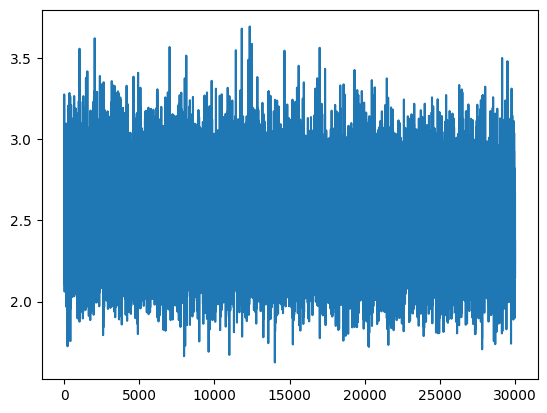

In [293]:
plt.plot(stepi, lossi)

In [303]:
emb = C[Xtr] # 32 x 3 x 2
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer weights + bias (3x2) x emb
logits = h @ W2 + b2 # 32 x 27 (output layer)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.298964738845825


In [307]:
emb = C[Xdev] # 32 x 3 x 2
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer weights + bias (3x2) x emb
logits = h @ W2 + b2 # 32 x 27 (output layer)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.2909843921661377


In [309]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size        # start with [0, 0, 0] i.e. '...'
    while True:
        emb = C[torch.tensor([context])]       # look up embeddings
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)   # hidden layer
        logits = h @ W2 + b2                    # output layer
        probs = F.softmax(logits, dim=1)        # probabilities
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]            # slide window
        out.append(itos[ix])                    # store character
        if ix == 0:                             # hit end token
            break
    print(''.join(out))

carmahela.
jhavi.
kimley.
thaylenah.
saler.
hete.
dellaha.
kaeli.
nellara.
chaily.
kaleigh.
ham.
pori.
quintis.
lilea.
vadbi.
watell.
dearixi.
fhaellinsle.
edde.
